# Benchmark Comparison: Size vs Energy

> Focus: compare all benchmark CSV files using small multiples, especially `size_bytes` vs `energy_mWh`.

In [53]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

In [54]:
base_dir = Path('../time')
csv_files = sorted(base_dir.glob('*_bench_2p10_2p20.csv'))

def get_algorithm_name(path: Path) -> str:
    return path.name.replace('_bench_2p10_2p20.csv', '').upper()

frames = []
for csv_file in csv_files:
    temp = pd.read_csv(csv_file)
    temp['algorithm'] = get_algorithm_name(csv_file)
    temp['source_file'] = csv_file.name
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)

print(f'Loaded {len(csv_files)} files and {len(df):,} rows')
display(df.head())

Loaded 10 files and 3,270 rows


,size_bytes,round_index,enc_ns,dec_ns,energy_mWh,algorithm,source_file
0,1024,1,712240,1249710,0.008456,AES,aes_bench_2p10_2p20.csv
1,1024,2,859570,911400,0.008456,AES,aes_bench_2p10_2p20.csv
2,1024,3,598740,402570,0.008456,AES,aes_bench_2p10_2p20.csv
3,1024,4,293710,249400,0.008456,AES,aes_bench_2p10_2p20.csv
4,1024,5,240160,165290,0.008456,AES,aes_bench_2p10_2p20.csv


In [55]:
display(
    df.groupby('algorithm', as_index=False)
      .agg(
          rows=('round_index', 'count'),
          min_size=('size_bytes', 'min'),
          max_size=('size_bytes', 'max'),
          mean_energy_mWh=('energy_mWh', 'mean')
      )
      .sort_values('algorithm')
)

print('Missing values by column:')
display(df.isna().sum())

,algorithm,rows,min_size,max_size,mean_energy_mWh
0,AES,330,1024,1048576,0.201779
1,AESGCM,330,1024,1048576,0.076839
2,ASCON,330,1024,1048576,0.185074
3,CHACHA20,330,1024,1048576,0.170134
4,ELEPHANT,300,1024,524288,2.677920
5,ELGAMAL,330,1024,1048576,0.197577
6,GIFTCOFB,330,1024,1048576,1.089289
7,GRAIN128AEAD,330,1024,1048576,1.742211
8,RSA_HYBRID,330,1024,1048576,0.214814
9,XOODYAK,330,1024,1048576,0.290987


Missing values by column:


size_bytes     0
round_index    0
enc_ns         0
dec_ns         0
energy_mWh     0
algorithm      0
source_file    0
dtype: int64

In [56]:
summary = (
    df.groupby(['algorithm', 'size_bytes'], as_index=False)
      .agg(
          energy_mean_mWh=('energy_mWh', 'mean'),
          energy_std_mWh=('energy_mWh', 'std'),
          enc_mean_ns=('enc_ns', 'mean'),
          dec_mean_ns=('dec_ns', 'mean'),
          runs=('round_index', 'count')
      )
)

display(summary.head(20))

,algorithm,size_bytes,energy_mean_mWh,energy_std_mWh,enc_mean_ns,dec_mean_ns,runs
0,AES,1024,0.008456,0.0,1.966960e+05,2.056847e+05,30
1,AES,2048,0.004305,0.0,1.230023e+05,1.511547e+05,30
2,AES,4096,0.008506,0.0,2.818957e+05,3.204127e+05,30
3,AES,8192,0.012786,0.0,3.865120e+05,5.066090e+05,30
4,AES,16384,0.025542,0.0,6.972147e+05,1.205989e+06,30
5,AES,32768,0.047188,0.0,1.378844e+06,2.084032e+06,30
6,AES,65536,0.080616,0.0,2.473738e+06,3.814463e+06,30
7,AES,131072,0.148870,0.0,4.862183e+06,6.809346e+06,30
8,AES,262144,0.284929,0.0,9.468304e+06,1.328775e+07,30
9,AES,524288,0.546978,0.0,1.827570e+07,2.533265e+07,30


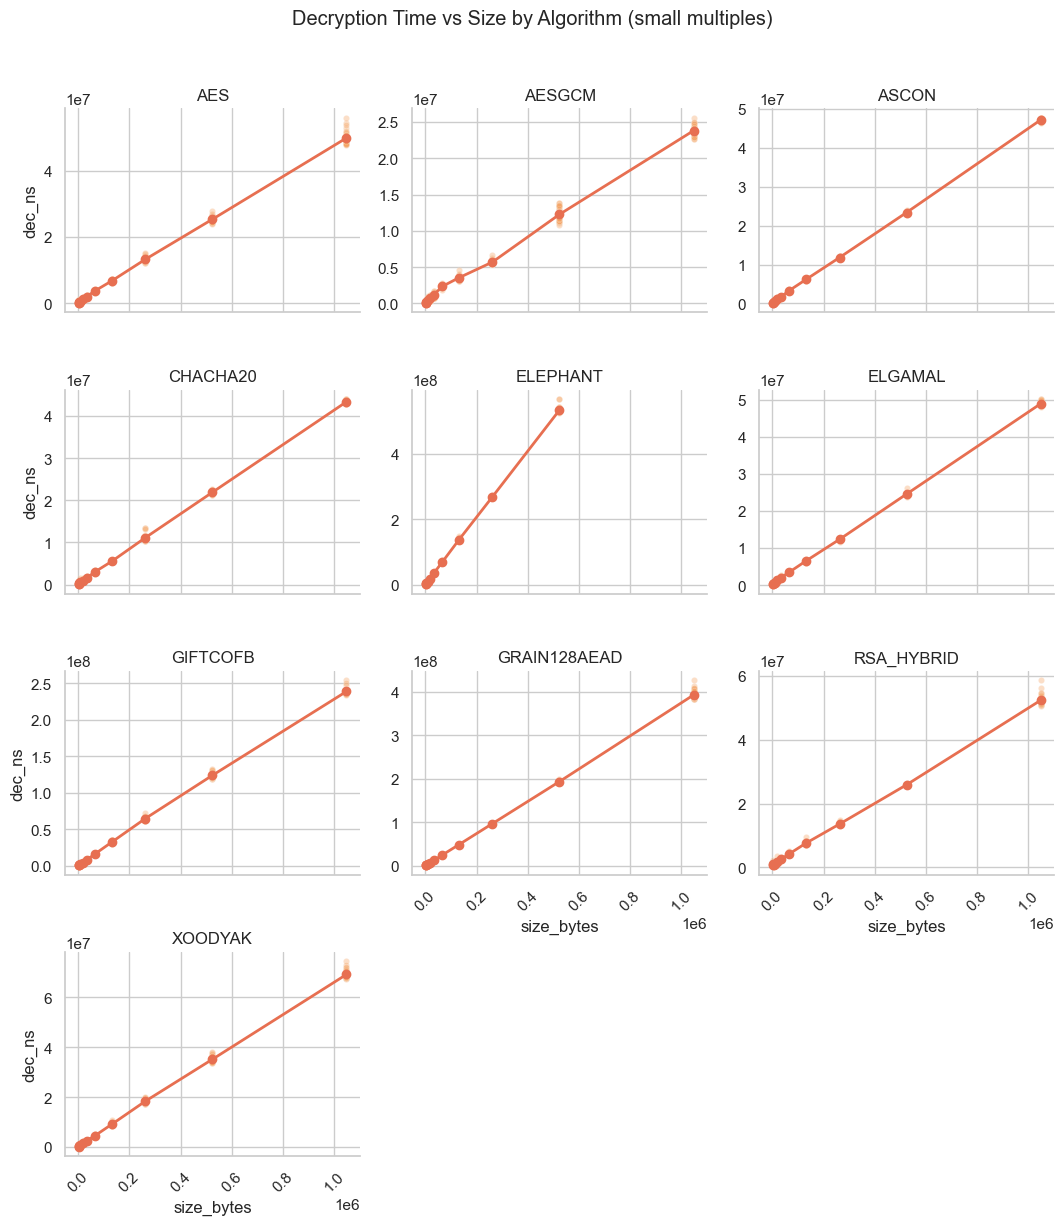

In [57]:
# Small multiples: decryption time (dec_ns) vs size
g_dec = sns.relplot(
    data=df,
    x='size_bytes',
    y='dec_ns',
    col='algorithm',
    col_wrap=3,
    kind='scatter',
    alpha=0.35,
    s=20,
    color='#f4a261',
    height=3.0,
    aspect=1.2,
    facet_kws={'sharey': False}
)

for algo, ax in g_dec.axes_dict.items():
    subset = summary[summary['algorithm'] == algo]
    ax.plot(
        subset['size_bytes'],
        subset['dec_mean_ns'],
        marker='o',
        linewidth=2,
        color='#e76f51'
    )
    ax.set_title(algo)
    ax.set_xlabel('size_bytes')
    ax.tick_params(axis='x', rotation=45)

g_dec.set_ylabels('dec_ns')
g_dec.fig.suptitle('Decryption Time vs Size by Algorithm (small multiples)', y=1.02)
plt.tight_layout()
plt.show()

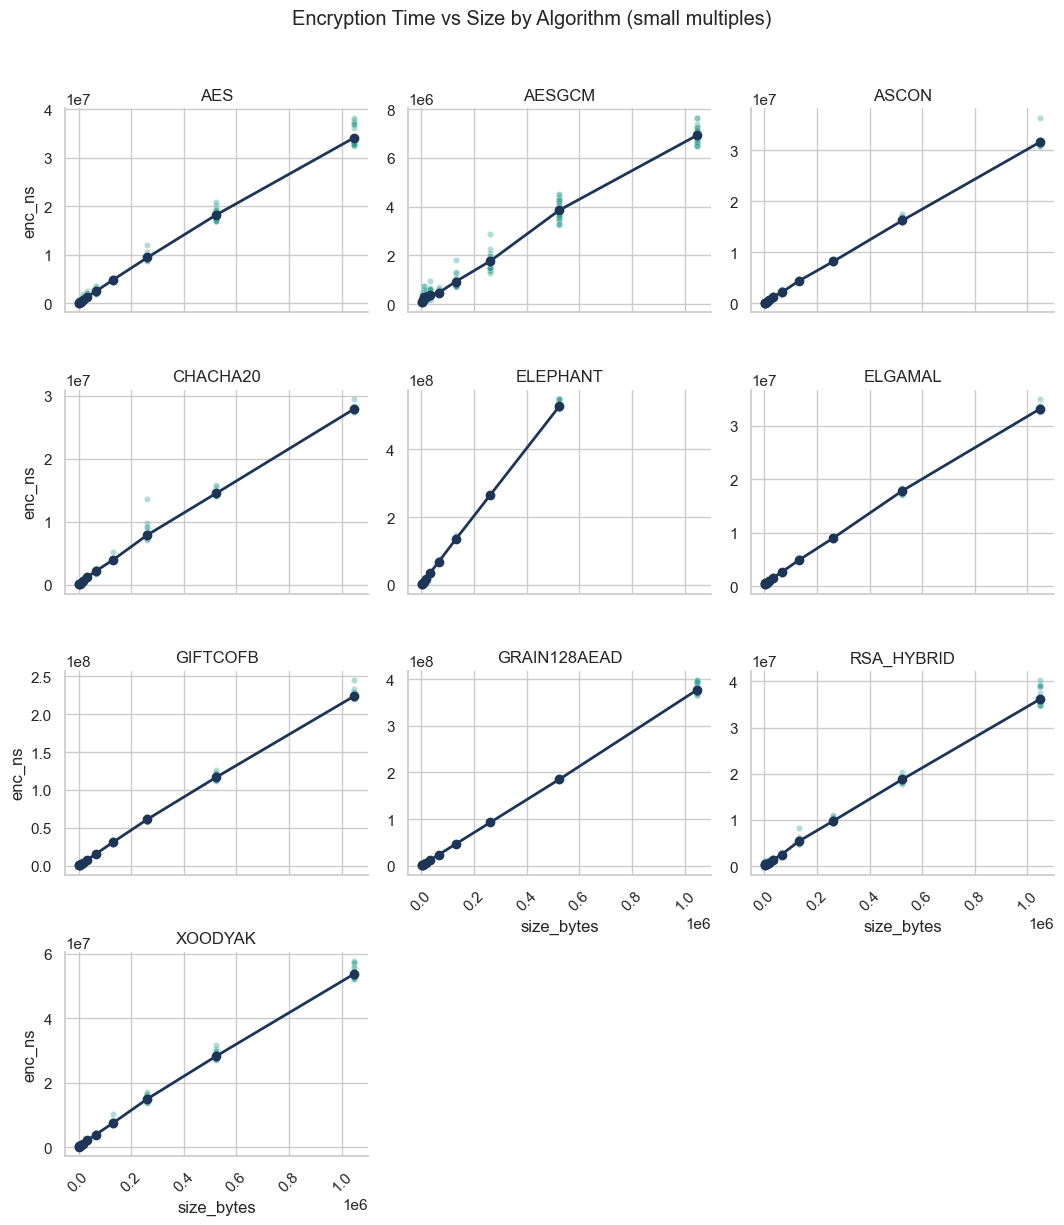

In [58]:
# Small multiples: encryption time (enc_ns) vs size
g_enc = sns.relplot(
    data=df,
    x='size_bytes',
    y='enc_ns',
    col='algorithm',
    col_wrap=3,
    kind='scatter',
    alpha=0.35,
    s=20,
    color='#2a9d8f',
    height=3.0,
    aspect=1.2,
    facet_kws={'sharey': False}
)

for algo, ax in g_enc.axes_dict.items():
    subset = summary[summary['algorithm'] == algo]
    ax.plot(
        subset['size_bytes'],
        subset['enc_mean_ns'],
        marker='o',
        linewidth=2,
        color='#1d3557'
    )
    ax.set_title(algo)
    ax.set_xlabel('size_bytes')
    ax.tick_params(axis='x', rotation=45)

g_enc.set_ylabels('enc_ns')
g_enc.fig.suptitle('Encryption Time vs Size by Algorithm (small multiples)', y=1.02)
plt.tight_layout()
plt.show()

## Time Comparison Tables (Raw + Normalized)
These tables summarize `enc_ns` and `dec_ns` by `size_bytes` and algorithm in a format that is easier to compare than scatter plots.

In [59]:
# Raw comparison table: mean times by size and algorithm
time_means = summary[['algorithm', 'size_bytes', 'enc_mean_ns', 'dec_mean_ns']].copy()

enc_raw_table = time_means.pivot(index='size_bytes', columns='algorithm', values='enc_mean_ns').sort_index()
dec_raw_table = time_means.pivot(index='size_bytes', columns='algorithm', values='dec_mean_ns').sort_index()

print('Encryption mean time (ns)')
display(enc_raw_table.round(0))

print('Decryption mean time (ns)')
display(dec_raw_table.round(0))

Encryption mean time (ns)


algorithm,AES,AESGCM,ASCON,CHACHA20,ELEPHANT,ELGAMAL,GIFTCOFB,GRAIN128AEAD,RSA_HYBRID,XOODYAK
size_bytes,,,,,,,,,,
1024,196696.0,74652.0,114570.0,89753.0,1427054.0,417038.0,451782.0,575200.0,369671.0,223724.0
2048,123002.0,105813.0,110667.0,91121.0,2350804.0,434955.0,548394.0,862094.0,178356.0,149690.0
4096,281896.0,188623.0,184518.0,153829.0,4603121.0,499156.0,975463.0,1597648.0,240325.0,284292.0
8192,386512.0,310011.0,381332.0,318271.0,8591480.0,598965.0,1933724.0,3105852.0,403744.0,530548.0
16384,697215.0,308870.0,598661.0,600655.0,17446679.0,880923.0,3782593.0,6302039.0,706619.0,905260.0
32768,1378844.0,396040.0,1311391.0,1158906.0,34517218.0,1555419.0,7654599.0,11988832.0,1413690.0,2027277.0
65536,2473738.0,470336.0,2164195.0,2128943.0,67884502.0,2595899.0,15387667.0,23696565.0,2512898.0,3857048.0
131072,4862183.0,930850.0,4400769.0,3913326.0,134934919.0,4859134.0,31015907.0,46824237.0,5398803.0,7447261.0
262144,9468304.0,1775385.0,8212088.0,7885436.0,265876528.0,9007274.0,61346529.0,93022829.0,9784190.0,14969425.0


Decryption mean time (ns)


algorithm,AES,AESGCM,ASCON,CHACHA20,ELEPHANT,ELGAMAL,GIFTCOFB,GRAIN128AEAD,RSA_HYBRID,XOODYAK
size_bytes,,,,,,,,,,
1024,205685.0,66277.0,143211.0,101945.0,1513212.0,251282.0,441418.0,574446.0,911848.0,215077.0
2048,151155.0,110307.0,161624.0,114089.0,2359175.0,317180.0,571653.0,908058.0,705390.0,184518.0
4096,320413.0,227631.0,277148.0,255062.0,4662505.0,442971.0,1085788.0,1599725.0,804773.0,368859.0
8192,506609.0,450941.0,525554.0,510685.0,8676479.0,614268.0,2029961.0,3203695.0,1136533.0,669774.0
16384,1205989.0,699076.0,1112487.0,915082.0,17571240.0,1290964.0,4093204.0,6497102.0,1807504.0,1538673.0
32768,2084032.0,1181159.0,1684833.0,1568665.0,34876634.0,1983523.0,8020623.0,12289848.0,2512805.0,2505925.0
65536,3814463.0,2344772.0,3325781.0,3033792.0,68580027.0,3478262.0,16242253.0,24405974.0,4240178.0,4569171.0
131072,6809346.0,3542878.0,6169494.0,5518571.0,136895248.0,6507696.0,32415532.0,48497080.0,7607859.0,9123622.0
262144,13287748.0,5705048.0,11811246.0,11122942.0,268031329.0,12316532.0,64709546.0,96805923.0,13585887.0,18373989.0


In [60]:
# Normalized comparison tables
norm = time_means.copy()

# Ratio to each algorithm's smallest size (usually 1024 bytes)
norm['enc_ratio_to_min_size'] = norm['enc_mean_ns'] / norm.groupby('algorithm')['enc_mean_ns'].transform('first')
norm['dec_ratio_to_min_size'] = norm['dec_mean_ns'] / norm.groupby('algorithm')['dec_mean_ns'].transform('first')

# Min-max scaling in [0, 1] per algorithm
norm['enc_minmax'] = norm.groupby('algorithm')['enc_mean_ns'].transform(
    lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0.0
)
norm['dec_minmax'] = norm.groupby('algorithm')['dec_mean_ns'].transform(
    lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0.0
)

enc_ratio_table = norm.pivot(index='size_bytes', columns='algorithm', values='enc_ratio_to_min_size').sort_index()
dec_ratio_table = norm.pivot(index='size_bytes', columns='algorithm', values='dec_ratio_to_min_size').sort_index()

enc_minmax_table = norm.pivot(index='size_bytes', columns='algorithm', values='enc_minmax').sort_index()
dec_minmax_table = norm.pivot(index='size_bytes', columns='algorithm', values='dec_minmax').sort_index()

print('Encryption normalized to smallest size (=1.00)')
display(enc_ratio_table.round(2))

print('Decryption normalized to smallest size (=1.00)')
display(dec_ratio_table.round(2))

print('Encryption min-max normalized per algorithm ([0, 1])')
display(enc_minmax_table.round(3))

print('Decryption min-max normalized per algorithm ([0, 1])')
display(dec_minmax_table.round(3))

Encryption normalized to smallest size (=1.00)


algorithm,AES,AESGCM,ASCON,CHACHA20,ELEPHANT,ELGAMAL,GIFTCOFB,GRAIN128AEAD,RSA_HYBRID,XOODYAK
size_bytes,,,,,,,,,,
1024,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
2048,0.63,1.42,0.97,1.02,1.65,1.04,1.21,1.50,0.48,0.67
4096,1.43,2.53,1.61,1.71,3.23,1.20,2.16,2.78,0.65,1.27
8192,1.97,4.15,3.33,3.55,6.02,1.44,4.28,5.40,1.09,2.37
16384,3.54,4.14,5.23,6.69,12.23,2.11,8.37,10.96,1.91,4.05
32768,7.01,5.31,11.45,12.91,24.19,3.73,16.94,20.84,3.82,9.06
65536,12.58,6.30,18.89,23.72,47.57,6.22,34.06,41.20,6.80,17.24
131072,24.72,12.47,38.41,43.60,94.55,11.65,68.65,81.41,14.60,33.29
262144,48.14,23.78,71.68,87.86,186.31,21.60,135.79,161.72,26.47,66.91


Decryption normalized to smallest size (=1.00)


algorithm,AES,AESGCM,ASCON,CHACHA20,ELEPHANT,ELGAMAL,GIFTCOFB,GRAIN128AEAD,RSA_HYBRID,XOODYAK
size_bytes,,,,,,,,,,
1024,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
2048,0.73,1.66,1.13,1.12,1.56,1.26,1.30,1.58,0.77,0.86
4096,1.56,3.43,1.94,2.50,3.08,1.76,2.46,2.78,0.88,1.72
8192,2.46,6.80,3.67,5.01,5.73,2.44,4.60,5.58,1.25,3.11
16384,5.86,10.55,7.77,8.98,11.61,5.14,9.27,11.31,1.98,7.15
32768,10.13,17.82,11.76,15.39,23.05,7.89,18.17,21.39,2.76,11.65
65536,18.55,35.38,23.22,29.76,45.32,13.84,36.80,42.49,4.65,21.24
131072,33.11,53.46,43.08,54.13,90.47,25.90,73.44,84.42,8.34,42.42
262144,64.60,86.08,82.47,109.11,177.13,49.01,146.59,168.52,14.90,85.43


Encryption min-max normalized per algorithm ([0, 1])


algorithm,AES,AESGCM,ASCON,CHACHA20,ELEPHANT,ELGAMAL,GIFTCOFB,GRAIN128AEAD,RSA_HYBRID,XOODYAK
size_bytes,,,,,,,,,,
1024,0.002,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.005,0.001
2048,0.000,0.005,0.000,0.000,0.002,0.001,0.000,0.001,0.000,0.000
4096,0.005,0.017,0.002,0.002,0.006,0.003,0.002,0.003,0.002,0.003
8192,0.008,0.034,0.009,0.008,0.014,0.006,0.007,0.007,0.006,0.007
16384,0.017,0.034,0.016,0.018,0.030,0.014,0.015,0.015,0.015,0.014
32768,0.037,0.047,0.038,0.038,0.063,0.035,0.032,0.030,0.034,0.035
65536,0.069,0.058,0.065,0.073,0.126,0.066,0.067,0.061,0.065,0.069
131072,0.139,0.125,0.136,0.138,0.254,0.136,0.137,0.123,0.145,0.136
262144,0.275,0.248,0.257,0.280,0.503,0.262,0.272,0.245,0.267,0.276


Decryption min-max normalized per algorithm ([0, 1])


algorithm,AES,AESGCM,ASCON,CHACHA20,ELEPHANT,ELGAMAL,GIFTCOFB,GRAIN128AEAD,RSA_HYBRID,XOODYAK
size_bytes,,,,,,,,,,
1024,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.004,0.000
2048,0.000,0.002,0.000,0.000,0.002,0.001,0.001,0.001,0.000,0.000
4096,0.003,0.007,0.003,0.004,0.006,0.004,0.003,0.003,0.002,0.003
8192,0.007,0.016,0.008,0.009,0.013,0.007,0.007,0.007,0.008,0.007
16384,0.021,0.027,0.021,0.019,0.030,0.021,0.015,0.015,0.021,0.020
32768,0.039,0.047,0.033,0.034,0.063,0.036,0.032,0.030,0.035,0.034
65536,0.074,0.096,0.068,0.068,0.126,0.066,0.066,0.061,0.068,0.064
131072,0.134,0.146,0.128,0.125,0.255,0.129,0.134,0.122,0.134,0.130
262144,0.265,0.238,0.248,0.255,0.502,0.248,0.270,0.246,0.249,0.264


In [61]:
# Normalization against the best algorithm at each size (best = 1.00)
fastest_base = time_means.copy()
fastest_base['energy_mean_mWh'] = summary['energy_mean_mWh'].values

# Best baselines per size (lower is better for time and energy)
fastest_base['enc_fastest_at_size_ns'] = fastest_base.groupby('size_bytes')['enc_mean_ns'].transform('min')
fastest_base['dec_fastest_at_size_ns'] = fastest_base.groupby('size_bytes')['dec_mean_ns'].transform('min')
fastest_base['energy_lowest_at_size_mWh'] = fastest_base.groupby('size_bytes')['energy_mean_mWh'].transform('min')

# Ratios vs best baseline at each size
fastest_base['enc_vs_fastest_ratio'] = fastest_base['enc_mean_ns'] / fastest_base['enc_fastest_at_size_ns']
fastest_base['dec_vs_fastest_ratio'] = fastest_base['dec_mean_ns'] / fastest_base['dec_fastest_at_size_ns']
fastest_base['energy_vs_lowest_ratio'] = fastest_base['energy_mean_mWh'] / fastest_base['energy_lowest_at_size_mWh']

enc_fastest_table = (
    fastest_base.pivot(index='size_bytes', columns='algorithm', values='enc_vs_fastest_ratio')
    .sort_index()
    .round(2)
)

dec_fastest_table = (
    fastest_base.pivot(index='size_bytes', columns='algorithm', values='dec_vs_fastest_ratio')
    .sort_index()
    .round(2)
)

energy_fastest_table = (
    fastest_base.pivot(index='size_bytes', columns='algorithm', values='energy_vs_lowest_ratio')
    .sort_index()
    .round(2)
)

enc_fastest_algo = (
    fastest_base.loc[fastest_base.groupby('size_bytes')['enc_mean_ns'].idxmin(), ['size_bytes', 'algorithm']]
    .set_index('size_bytes')
    .rename(columns={'algorithm': 'best_enc_algorithm'})
)

dec_fastest_algo = (
    fastest_base.loc[fastest_base.groupby('size_bytes')['dec_mean_ns'].idxmin(), ['size_bytes', 'algorithm']]
    .set_index('size_bytes')
    .rename(columns={'algorithm': 'best_dec_algorithm'})
)

energy_best_algo = (
    fastest_base.loc[fastest_base.groupby('size_bytes')['energy_mean_mWh'].idxmin(), ['size_bytes', 'algorithm']]
    .set_index('size_bytes')
    .rename(columns={'algorithm': 'best_energy_algorithm'})
)

print('Encryption time normalized by fastest algorithm at each size (1.00 = fastest)')
display(enc_fastest_table.join(enc_fastest_algo))

print('Decryption time normalized by fastest algorithm at each size (1.00 = fastest)')
display(dec_fastest_table.join(dec_fastest_algo))

print('Energy normalized by lowest-energy algorithm at each size (1.00 = lowest)')
display(energy_fastest_table.join(energy_best_algo))

Encryption time normalized by fastest algorithm at each size (1.00 = fastest)


,AES,AESGCM,ASCON,CHACHA20,ELEPHANT,ELGAMAL,GIFTCOFB,GRAIN128AEAD,RSA_HYBRID,XOODYAK,best_enc_algorithm
size_bytes,,,,,,,,,,,
1024,2.63,1.00,1.53,1.20,19.12,5.59,6.05,7.71,4.95,3.00,AESGCM
2048,1.35,1.16,1.21,1.00,25.80,4.77,6.02,9.46,1.96,1.64,CHACHA20
4096,1.83,1.23,1.20,1.00,29.92,3.24,6.34,10.39,1.56,1.85,CHACHA20
8192,1.25,1.00,1.23,1.03,27.71,1.93,6.24,10.02,1.30,1.71,AESGCM
16384,2.26,1.00,1.94,1.94,56.49,2.85,12.25,20.40,2.29,2.93,AESGCM
32768,3.48,1.00,3.31,2.93,87.16,3.93,19.33,30.27,3.57,5.12,AESGCM
65536,5.26,1.00,4.60,4.53,144.33,5.52,32.72,50.38,5.34,8.20,AESGCM
131072,5.22,1.00,4.73,4.20,144.96,5.22,33.32,50.30,5.80,8.00,AESGCM
262144,5.33,1.00,4.63,4.44,149.76,5.07,34.55,52.40,5.51,8.43,AESGCM


Decryption time normalized by fastest algorithm at each size (1.00 = fastest)


,AES,AESGCM,ASCON,CHACHA20,ELEPHANT,ELGAMAL,GIFTCOFB,GRAIN128AEAD,RSA_HYBRID,XOODYAK,best_dec_algorithm
size_bytes,,,,,,,,,,,
1024,3.10,1.0,2.16,1.54,22.83,3.79,6.66,8.67,13.76,3.25,AESGCM
2048,1.37,1.0,1.47,1.03,21.39,2.88,5.18,8.23,6.39,1.67,AESGCM
4096,1.41,1.0,1.22,1.12,20.48,1.95,4.77,7.03,3.54,1.62,AESGCM
8192,1.12,1.0,1.17,1.13,19.24,1.36,4.50,7.10,2.52,1.49,AESGCM
16384,1.73,1.0,1.59,1.31,25.13,1.85,5.86,9.29,2.59,2.20,AESGCM
32768,1.76,1.0,1.43,1.33,29.53,1.68,6.79,10.40,2.13,2.12,AESGCM
65536,1.63,1.0,1.42,1.29,29.25,1.48,6.93,10.41,1.81,1.95,AESGCM
131072,1.92,1.0,1.74,1.56,38.64,1.84,9.15,13.69,2.15,2.58,AESGCM
262144,2.33,1.0,2.07,1.95,46.98,2.16,11.34,16.97,2.38,3.22,AESGCM


Energy normalized by lowest-energy algorithm at each size (1.00 = lowest)


,AES,AESGCM,ASCON,CHACHA20,ELEPHANT,ELGAMAL,GIFTCOFB,GRAIN128AEAD,RSA_HYBRID,XOODYAK,best_energy_algorithm
size_bytes,,,,,,,,,,,
1024,2.00,1.0,1.00,1.03,9.04,2.01,3.04,4.04,4.01,2.04,AESGCM
2048,1.02,1.0,1.00,1.00,14.04,3.00,4.04,6.01,3.01,1.00,AESGCM
4096,1.00,1.0,1.00,1.01,14.03,1.52,3.49,5.00,2.00,1.01,ASCON
8192,1.00,1.0,1.01,1.04,16.93,1.33,4.02,6.30,1.67,1.34,AES
16384,1.99,1.0,1.67,1.65,34.38,2.30,7.93,12.55,2.65,2.64,AESGCM
32768,2.21,1.0,1.79,1.80,40.73,2.18,9.35,14.31,2.40,2.80,AESGCM
65536,2.11,1.0,1.88,1.79,44.66,2.00,10.43,15.74,2.22,2.77,AESGCM
131072,2.51,1.0,2.29,2.01,57.27,2.43,13.36,20.14,2.74,3.51,AESGCM
262144,3.04,1.0,2.72,2.58,71.30,2.85,16.85,25.37,3.12,4.48,AESGCM


## Small Multiples for Encryption and Decryption Time
These views compare `enc_ns` and `dec_ns` across algorithms as a function of `size_bytes`.

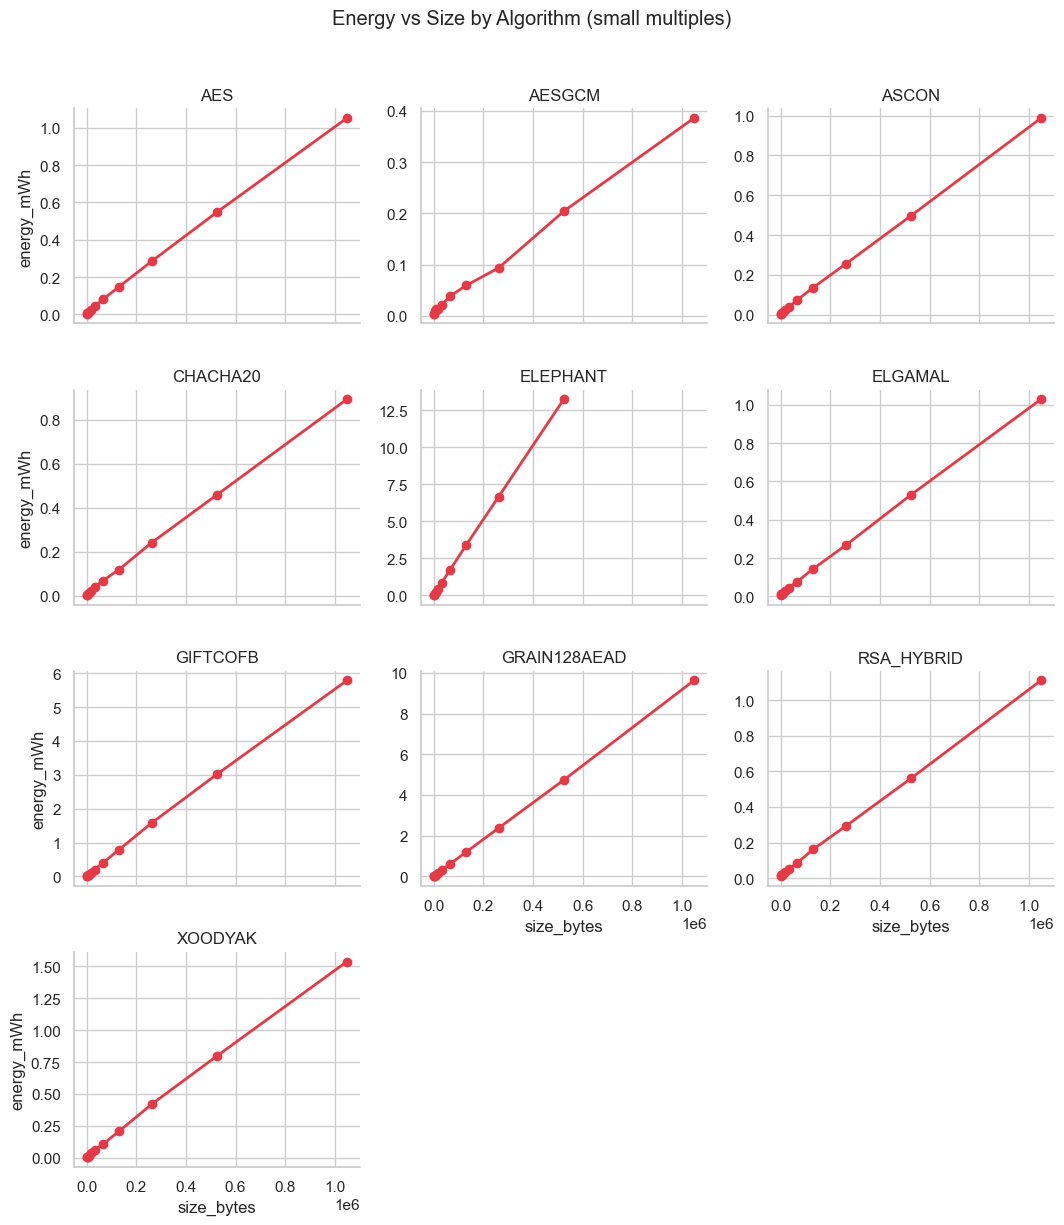

In [62]:
# Small multiples: per algorithm scatter + mean line
g = sns.relplot(
    data=df,
    x='size_bytes',
    y='energy_mWh',
    col='algorithm',
    col_wrap=3,
    kind='scatter',
    alpha=0.35,
    s=20,
    color='#457b9d',
    height=3.0,
    aspect=1.2,
    facet_kws={'sharey': False}
)

for ax, algo in zip(g.axes.flat, sorted(df['algorithm'].unique())):
    subset = summary[summary['algorithm'] == algo]
    ax.plot(
        subset['size_bytes'],
        subset['energy_mean_mWh'],
        marker='o',
        linewidth=2,
        color='#e63946'
    )
    ax.set_title(algo)

g.set_axis_labels('size_bytes', 'energy_mWh')
g.fig.suptitle('Energy vs Size by Algorithm (small multiples)', y=1.02)
plt.tight_layout()
plt.show()

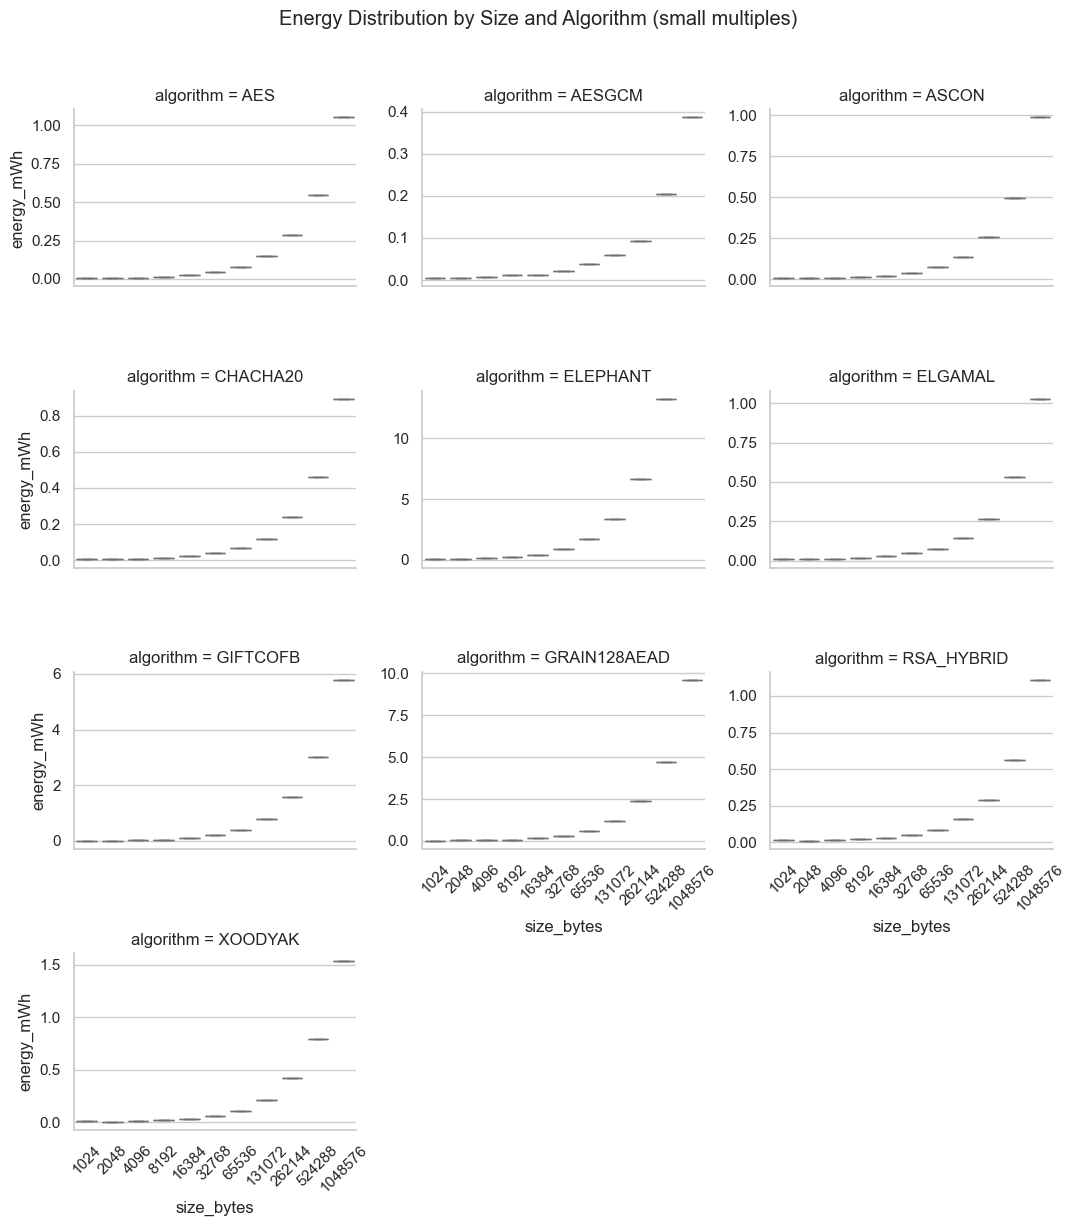

In [63]:
# Small multiples: distribution of energy at each size
g = sns.catplot(
    data=df,
    x='size_bytes',
    y='energy_mWh',
    col='algorithm',
    col_wrap=3,
    kind='box',
    color='#8ecae6',
    fliersize=1.5,
    height=3.0,
    aspect=1.2,
    sharey=False
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

g.set_axis_labels('size_bytes', 'energy_mWh')
g.fig.suptitle('Energy Distribution by Size and Algorithm (small multiples)', y=1.02)
plt.tight_layout()
plt.show()

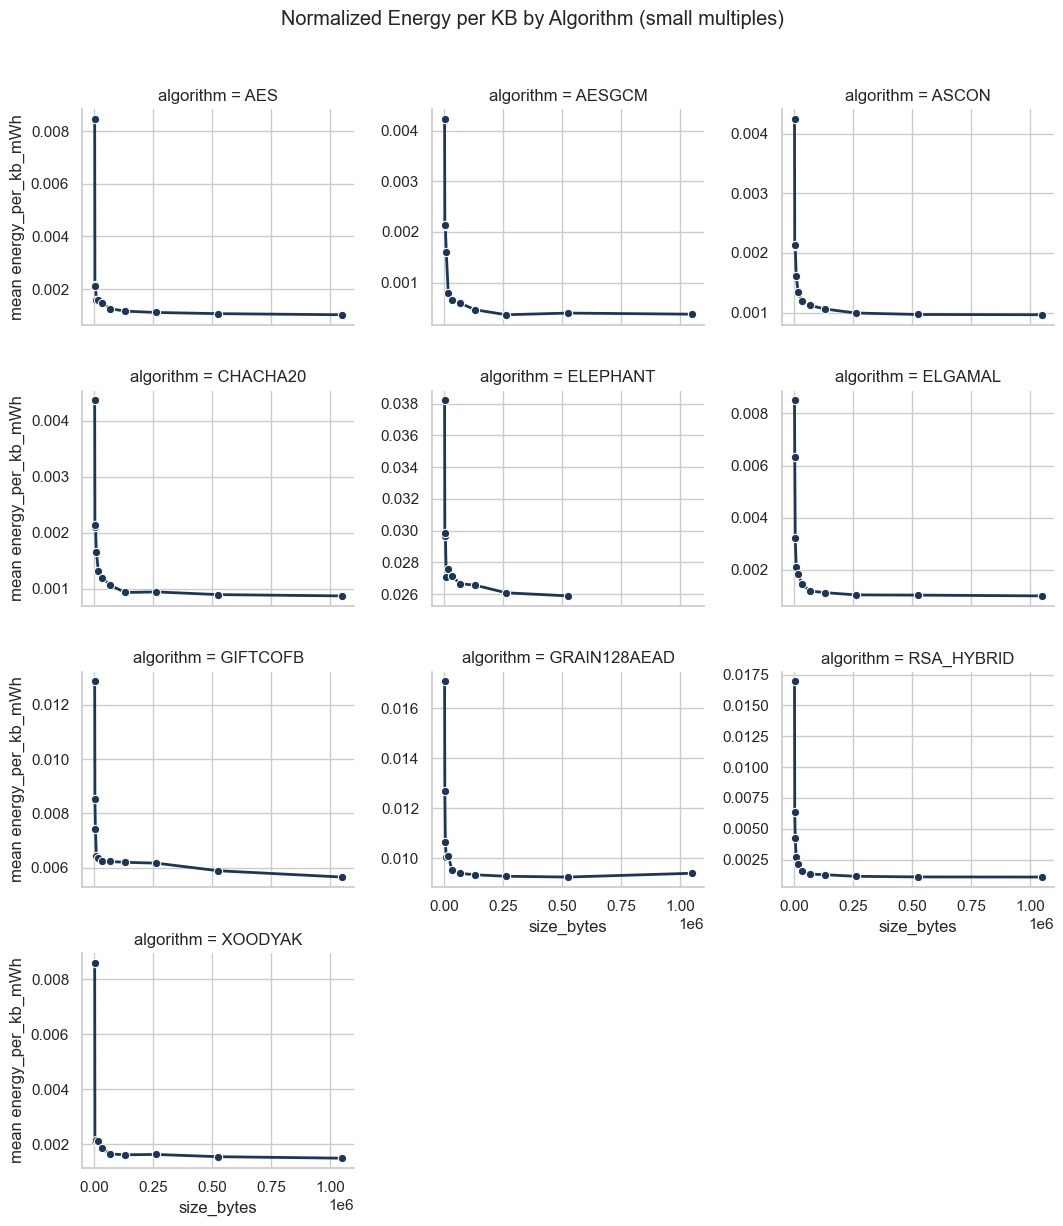

In [64]:
# Normalized metric: energy per KB
df['energy_per_kb_mWh'] = df['energy_mWh'] / (df['size_bytes'] / 1024)

norm_summary = (
    df.groupby(['algorithm', 'size_bytes'], as_index=False)
      .agg(energy_per_kb_mean=('energy_per_kb_mWh', 'mean'))
)

g = sns.relplot(
    data=norm_summary,
    x='size_bytes',
    y='energy_per_kb_mean',
    col='algorithm',
    col_wrap=3,
    kind='line',
    marker='o',
    linewidth=2,
    color='#1d3557',
    height=3.0,
    aspect=1.2,
    facet_kws={'sharey': False}
)

g.set_axis_labels('size_bytes', 'mean energy_per_kb_mWh')
g.fig.suptitle('Normalized Energy per KB by Algorithm (small multiples)', y=1.02)
plt.tight_layout()
plt.show()

In [65]:
# Quick ranking: lowest average energy by algorithm
ranking = (
    df.groupby('algorithm', as_index=False)
      .agg(
          avg_energy_mWh=('energy_mWh', 'mean'),
          avg_energy_per_kb_mWh=('energy_per_kb_mWh', 'mean')
      )
      .sort_values(['avg_energy_mWh', 'avg_energy_per_kb_mWh'])
)

display(ranking)

,algorithm,avg_energy_mWh,avg_energy_per_kb_mWh
1,AESGCM,0.076839,0.001249
3,CHACHA20,0.170134,0.001593
2,ASCON,0.185074,0.001613
5,ELGAMAL,0.197577,0.002628
0,AES,0.201779,0.002094
8,RSA_HYBRID,0.214814,0.003624
9,XOODYAK,0.290987,0.002452
6,GIFTCOFB,1.089289,0.007086
7,GRAIN128AEAD,1.742211,0.010612
4,ELEPHANT,2.677920,0.028466
